# 03 — Model and validation

A clean, end-to-end pipeline for developing the production model of **one** instrument, and for testing it once on data it has never seen.

## Principles
- **Train / dev / test split.** The TEST split is the last segment and stays **LOCKED**: nothing before the final section of this notebook uses it. It is evaluated exactly once, at the end, with every parameter frozen.
- **One model**, trained on TRAIN (with internal early stopping) and evaluated on DEV.
- **Threshold chosen on DEV full-data** (including TIMEOUT bars), not on the optimistic filtered data.
- **Walk-forward** as a consistency check (the chosen threshold only filters which trades are shown; it does not change the training).
- **Circuit breaker** to fix the cooldown and drawdown trigger.
- No model export here: the `.pkl` artifact is produced separately by `scripts/export_model.py`, from this same frozen configuration.

## Order
1. Config → 2. Load + split → 3. Train (TRAIN) + predict (DEV) → 4. Prepare DEV full-data → 5. Threshold table (filtered vs full) → 6. Choose threshold → 7. Benchmarks → 8. CI + PnL → 9. Feature importance → 10. Walk-forward (consistency) → 11. Temporal stability → 12. Circuit breaker → 13. Final model summary → 14–17. One-time validation on the locked TEST split.

*Naming note:* `ic` in variable and column names (`ic_boot`, `full_ic_lo%`, `ic>0`) stands for the 95% bootstrap confidence interval.

In [1]:
# === Cell 1: Configuration and imports ===
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

# ----------- Paths -----------
DATA_PATH = pathlib.Path('../data/USDJPY_15M_features.parquet')   # output of notebook 02
FEATURE_LIST_PATH = pathlib.Path('../data/feature_list.txt')
OUTPUT_DIR = pathlib.Path('../outputs/reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------- Train / dev / test SPLIT -----------
# The TEST split is the LAST segment and stays LOCKED: nothing before the final section
# of this notebook uses it. It is evaluated once, at the very end, with everything frozen.
TRAIN_FRAC = 0.60
DEV_FRAC   = 0.20
# TEST_FRAC = 0.20 implied (the remainder)
EMBARGO = 18   # = HORIZON; gap between splits so forward-looking labels cannot leak across them

# ----------- Strategy parameters (must match notebook 01) -----------
# K_TP, K_SL and HORIZON are fixed here and must equal the values used to build the target.
K_TP = 2.5
K_SL = 2.5
HORIZON = 18

# ----------- LightGBM (conservative) -----------
LGB_PARAMS = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'learning_rate': 0.02, 'num_leaves': 31, 'min_data_in_leaf': 200,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'lambda_l2': 1.0, 'verbose': -1, 'num_threads': -1, 'seed': 42,
}
N_BOOST_MAX = 2000
EARLY_STOP = 100

with open(FEATURE_LIST_PATH) as f:
    SELECTED_FEATURES = [ln.strip() for ln in f if ln.strip()]

print('Configuration:')
print(f'  Split: train={TRAIN_FRAC:.0%} dev={DEV_FRAC:.0%} test={1-TRAIN_FRAC-DEV_FRAC:.0%} (embargo {EMBARGO})')
print(f'  Strategy: K_TP={K_TP} K_SL={K_SL} H={HORIZON}')
print(f'  Features: {len(SELECTED_FEATURES)}')
print(f'  LightGBM: lr={LGB_PARAMS["learning_rate"]}, leaves={LGB_PARAMS["num_leaves"]}, min_leaf={LGB_PARAMS["min_data_in_leaf"]}')
print()
print('  NOTE: the TEST split stays untouched; everything before the final section uses TRAIN+DEV only.')

Configuration:
  Split: train=60% dev=20% test=20% (embargo 18)
  Strategy: K_TP=2.5 K_SL=2.5 H=18
  Features: 21
  LightGBM: lr=0.02, leaves=31, min_leaf=200

  NOTE: the TEST split stays untouched; everything before the final section uses TRAIN+DEV only.


In [2]:
# === Cell 2: Load the data and SPLIT into train / dev / test ===
df = pd.read_parquet(DATA_PATH).sort_values('Datetime').reset_index(drop=True)
df['Datetime'] = pd.to_datetime(df['Datetime'])

missing = [c for c in SELECTED_FEATURES if c not in df.columns]
assert not missing, f'Missing features: {missing}'
for need in ['Open','High','Low','Close','cost_pct','tp_pct','sl_pct','target']:
    assert need in df.columns, f'Column {need} missing from the parquet (created by notebooks 01/02)'

print(f'Dataset: {len(df):,} rows | {df["Datetime"].min()} → {df["Datetime"].max()}')
print(f'Target balance (TP rate): {df["target"].mean():.4f}')

# --- Chronological split with embargo ---
n = len(df)
i_tr = int(n * TRAIN_FRAC)
i_dev = int(n * (TRAIN_FRAC + DEV_FRAC))

train = df.iloc[:i_tr - EMBARGO].reset_index(drop=True)
dev   = df.iloc[i_tr:i_dev - EMBARGO].reset_index(drop=True)
test  = df.iloc[i_dev:].reset_index(drop=True)   # LOCKED — not used until the final section

print('\n=== SPLIT (with embargo) ===')
for name, d in [('TRAIN', train), ('DEV', dev), ('TEST (LOCKED)', test)]:
    print(f'  {name:<18} {len(d):>7,} rows | {d["Datetime"].min()} → {d["Datetime"].max()}')
print(f'\n  TRAIN balance: {train["target"].mean():.4f} | DEV balance: {dev["target"].mean():.4f}')
print('  The TEST split is not used until the final section of this notebook.')

Dataset: 57,251 rows | 2022-05-24 07:45:00 → 2026-05-27 16:45:00
Target balance (TP rate): 0.5019

=== SPLIT (with embargo) ===
  TRAIN               34,332 rows | 2022-05-24 07:45:00 → 2024-10-16 10:00:00
  DEV                 11,432 rows | 2024-10-16 15:15:00 → 2025-07-29 05:30:00
  TEST (LOCKED)       11,451 rows | 2025-07-29 10:45:00 → 2026-05-27 16:45:00

  TRAIN balance: 0.5075 | DEV balance: 0.4827
  The TEST split is not used until the final section of this notebook.


In [3]:
# === Cell 3: Train ONE model on TRAIN (internal early stopping) and predict on DEV ===
# A single model trained on the whole TRAIN split. The last 20% of TRAIN is used
# for early stopping. DEV is the development data where results are inspected
# and the threshold is chosen. TEST stays untouched.

n_train = len(train)
vs = int(n_train * 0.8)
X_tr = train.iloc[:vs][SELECTED_FEATURES].values
y_tr = train.iloc[:vs]['target'].values
X_es = train.iloc[vs:][SELECTED_FEATURES].values   # early-stopping split
y_es = train.iloc[vs:]['target'].values

dtr = lgb.Dataset(X_tr, label=y_tr, feature_name=SELECTED_FEATURES)
des = lgb.Dataset(X_es, label=y_es, feature_name=SELECTED_FEATURES, reference=dtr)
model = lgb.train(LGB_PARAMS, dtr, num_boost_round=N_BOOST_MAX,
                  valid_sets=[des], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

# Predictions
dev = dev.copy()
dev['pred_proba'] = model.predict(dev[SELECTED_FEATURES].values, num_iteration=model.best_iteration)

print(f'Model trained. best_iteration={model.best_iteration}')
print(f'  AUC early-stop split: {roc_auc_score(y_es, model.predict(X_es, num_iteration=model.best_iteration)):.4f}')
print(f'  AUC DEV:              {roc_auc_score(dev["target"], dev["pred_proba"]):.4f}')
print(f'  LogLoss DEV:          {log_loss(dev["target"], np.clip(dev["pred_proba"],1e-7,1-1e-7)):.4f}')
print(f'  Brier DEV:            {brier_score_loss(dev["target"], dev["pred_proba"]):.4f}')

# Distribution of predicted probabilities on DEV (sanity check: does the model separate?)
print('\nDistribution of pred_proba on DEV:')
print(pd.Series(dev['pred_proba']).describe().round(4).to_string())

Model trained. best_iteration=26
  AUC early-stop split: 0.5339
  AUC DEV:              0.5291
  LogLoss DEV:          0.6926
  Brier DEV:            0.2497

Distribution of pred_proba on DEV:
count    11432.0000
mean         0.5134
std          0.0231
min          0.3998
25%          0.5019
50%          0.5152
75%          0.5267
max          0.5859


---
## DEV evaluation: filtered data vs full-data
The parquet only contains rows where TP or SL was resolved. For realistic results we rebuild ALL bars in the DEV date range (including TIMEOUT bars) and evaluate on those.

In [4]:
# === Cell 4: Prepare the FULL-DATA evaluation on DEV (includes TIMEOUT) ===
# The feature parquet IS FILTERED (TP/SL rows only: no TIMEOUT bars, no excluded hours).
# A realistic evaluation must apply the model to ALL bars in the DEV range,
# including those that close by TIMEOUT.
#
# Those bars live in the UNFILTERED parquet produced by notebook 02 (cell 11b):
#   ../data/USDJPY_15M_features_FULL.parquet
# It holds the SAME features (shift(1) already applied) over the complete series,
# plus OHLC/atr_exante/cost_pct. Here we:
#   1) load that parquet
#   2) take the DEV date range with ALL its bars
#   3) compute TP/SL/TIMEOUT exits
#   4) apply the SAME model (frozen probability rule)

FULL_PATH = pathlib.Path('../data/USDJPY_15M_features_FULL.parquet')
assert FULL_PATH.exists(), (
    f'Missing {FULL_PATH}. Run cell 11b of notebook 02 to create it '
    '(unfiltered features over all bars).')

full = pd.read_parquet(FULL_PATH).sort_values('Datetime').reset_index(drop=True)
full['Datetime'] = pd.to_datetime(full['Datetime'])

def compute_first_hit_full(highs, lows, closes, opens, atr_ex, k_tp, k_sl, horizon):
    nrows = len(highs)
    lo_out = np.full(nrows, np.nan); lo_exit = np.full(nrows, np.nan)
    sh_out = np.full(nrows, np.nan); sh_exit = np.full(nrows, np.nan)
    for i in range(nrows - horizon):
        a = atr_ex[i]; o = opens[i]
        if not (np.isfinite(a) and np.isfinite(o)):
            continue
        tp_l = o + k_tp*a; sl_l = o - k_sl*a
        tp_s = o - k_tp*a; sl_s = o + k_sl*a
        dl = False
        for k in range(1, horizon+1):
            hi = highs[i+k]; lo = lows[i+k]
            tph = hi >= tp_l; slh = lo <= sl_l
            if tph and slh: lo_out[i]=-1; lo_exit[i]=sl_l; dl=True; break
            elif tph:       lo_out[i]= 1; lo_exit[i]=tp_l; dl=True; break
            elif slh:       lo_out[i]=-1; lo_exit[i]=sl_l; dl=True; break
        if not dl: lo_out[i]=0; lo_exit[i]=closes[i+horizon]
        ds = False
        for k in range(1, horizon+1):
            hi = highs[i+k]; lo = lows[i+k]
            tph = lo <= tp_s; slh = hi >= sl_s
            if tph and slh: sh_out[i]=-1; sh_exit[i]=sl_s; ds=True; break
            elif tph:       sh_out[i]= 1; sh_exit[i]=tp_s; ds=True; break
            elif slh:       sh_out[i]=-1; sh_exit[i]=sl_s; ds=True; break
        if not ds: sh_out[i]=0; sh_exit[i]=closes[i+horizon]
    return lo_out, lo_exit, sh_out, sh_exit

# DEV range (same dates as the filtered split), but with ALL bars
dev_start, dev_end = dev['Datetime'].min(), dev['Datetime'].max()
dev_full = full[(full['Datetime'] >= dev_start) & (full['Datetime'] <= dev_end)].reset_index(drop=True).copy()

# Exits over the complete range
lo, le, so, se = compute_first_hit_full(
    dev_full['High'].values, dev_full['Low'].values, dev_full['Close'].values,
    dev_full['Open'].values, dev_full['atr_exante'].values, K_TP, K_SL, HORIZON)
dev_full['long_outcome']=lo; dev_full['long_exit']=le
dev_full['short_outcome']=so; dev_full['short_exit']=se

# Apply the model (frozen probability rule) to ALL bars
dev_full['pred_proba'] = model.predict(dev_full[SELECTED_FEATURES].values, num_iteration=model.best_iteration)
dev_full = dev_full.dropna(subset=['long_exit','short_exit']).reset_index(drop=True)

# How many bars are TIMEOUT (resolved neither TP nor SL)
n_timeout_long = int((dev_full['long_outcome']==0).sum())
print(f'DEV filtered (TP/SL only):    {len(dev):,} rows')
print(f'DEV full-data (all bars):     {len(dev_full):,} rows')
print(f'  TIMEOUT bars (long):        {n_timeout_long:,} ({n_timeout_long/len(dev_full)*100:.1f}%)')
print(f'  → N_full in the threshold table should therefore be much larger than N_filt.')

DEV filtered (TP/SL only):    11,432 rows
DEV full-data (all bars):     19,329 rows
  TIMEOUT bars (long):        5,893 (30.5%)
  → N_full in the threshold table should therefore be much larger than N_filt.


In [5]:
# === Cell 5: Threshold table — FILTERED vs FULL-DATA, side by side ===
# For each threshold, results are shown on:
#   - FILTERED (TP/SL only): optimistic, NOT realistic
#   - FULL-DATA (includes TIMEOUT): what live trading would actually experience
# The threshold is chosen from the FULL-DATA columns.

RT_COST = 2.0  # the spread is crossed at entry AND at exit

def returns_filtered(d, thr_long, thr_short):
    pred=d['pred_proba'].values; target=d['target'].values
    tp=d['tp_pct'].values; sl=d['sl_pct'].values; cost=d['cost_pct'].values
    lm=pred>thr_long; sm=pred<thr_short
    r=np.zeros(len(d))
    r[lm]=np.where(target[lm]==1, tp[lm]-RT_COST*cost[lm], -sl[lm]-RT_COST*cost[lm])
    r[sm]=np.where(target[sm]==0, tp[sm]-RT_COST*cost[sm], -sl[sm]-RT_COST*cost[sm])
    return r[lm|sm]

def returns_fulldata(d, thr_long, thr_short):
    pred=d['pred_proba'].values; o=d['Open'].values; cost=d['cost_pct'].values
    le=d['long_exit'].values; se=d['short_exit'].values
    lm=pred>thr_long; sm=pred<thr_short
    r=np.zeros(len(d))
    r[lm]=(le[lm]-o[lm])/o[lm] - RT_COST*cost[lm]
    r[sm]=(o[sm]-se[sm])/o[sm] - RT_COST*cost[sm]
    return r[lm|sm]

def ic_boot(x, n_boot=2000, seed=42):
    if len(x)<20: return np.nan, np.nan, np.nan
    rng=np.random.default_rng(seed)
    m=np.array([x[rng.integers(0,len(x),len(x))].mean() for _ in range(n_boot)])
    return x.mean(), np.percentile(m,2.5), np.percentile(m,97.5)

thresholds = [(0.51,0.49),(0.52,0.48),(0.53,0.47),(0.54,0.46),(0.55,0.45),(0.57,0.43),(0.60,0.40)]
rows=[]
for tl,ts in thresholds:
    rf = returns_filtered(dev, tl, ts)
    rfull = returns_fulldata(dev_full, tl, ts)
    if len(rfull) < 30:
        continue
    mf, _, _ = ic_boot(rf)
    mu, lo, hi = ic_boot(rfull)
    rows.append({
        'thr_L':tl, 'thr_S':ts,
        'N_filt':len(rf), 'mean_filt%':rf.mean()*100, 'sum_filt%':rf.sum()*100,
        'hit_filt':(rf>0).mean(),
        'N_full':len(rfull), 'mean_full%':rfull.mean()*100, 'sum_full%':rfull.sum()*100,
        'hit_full':(rfull>0).mean(),
        'full_ic_lo%':lo*100, 'full_ic_hi%':hi*100,
        'full_ic>0': lo>0,
    })
df_thr = pd.DataFrame(rows)
print('THRESHOLDS on DEV — FILTERED (optimistic) vs FULL-DATA (realistic):\n')
print(df_thr.round(4).to_string(index=False))
print('\n→ The threshold is chosen from the FULL columns (mean_full%, sum_full%, full_ic>0).')
print('  FILTERED is shown only to expose how much optimism ignoring TIMEOUT bars adds.')

THRESHOLDS on DEV — FILTERED (optimistic) vs FULL-DATA (realistic):

 thr_L  thr_S  N_filt  mean_filt%  sum_filt%  hit_filt  N_full  mean_full%  sum_full%  hit_full  full_ic_lo%  full_ic_hi%  full_ic>0
  0.51   0.49    8343     -0.0071   -59.0472    0.5011   14067     -0.0097  -136.7172    0.4968      -0.0131      -0.0063      False
  0.52   0.48    5186     -0.0018    -9.2386    0.5150    8757     -0.0067   -58.6516    0.5051      -0.0109      -0.0024      False
  0.53   0.47    2721      0.0078    21.3521    0.5443    4708     -0.0015    -6.8988    0.5225      -0.0071       0.0041      False
  0.54   0.46    1352      0.0287    38.7805    0.5939    2465      0.0079    19.3967    0.5489       0.0001       0.0155       True
  0.55   0.45     721      0.0547    39.4206    0.6533    1314      0.0208    27.2796    0.5601       0.0101       0.0313       True
  0.57   0.43     179      0.0452     8.0942    0.6313     310      0.0178     5.5101    0.5452      -0.0014       0.0379      False


In [6]:
# === Cell 6: Choose the threshold (on DEV full-data) ===
# By default, picks the threshold with the highest sum_full% among those whose full-data CI > 0
# and that have a minimum number of trades. A manual override is available below.

MIN_TRADES_FULL = 200   # reasonable minimum on DEV (DEV is ~20% of the data)

elig = df_thr[(df_thr['full_ic>0']) & (df_thr['N_full'] >= MIN_TRADES_FULL)].copy()
if len(elig) == 0:
    print('⚠️  No threshold has a full-data CI > 0 with enough trades on DEV.')
    print('    That is already a warning sign about the edge. The highest sum_full is chosen anyway.')
    elig = df_thr[df_thr['N_full'] >= MIN_TRADES_FULL].copy()
    if len(elig) == 0:
        elig = df_thr.copy()

best = elig.loc[elig['sum_full%'].idxmax()]
best_thr_long = float(best['thr_L'])
best_thr_short = float(best['thr_S'])

# === Manual override (optional) ===
# Uncomment and edit to force specific thresholds:
# best_thr_long, best_thr_short = 0.54, 0.46

print(f'Chosen threshold (full-data DEV): LONG>{best_thr_long} | SHORT<{best_thr_short}')
print(f'  N_full={int(best["N_full"])} | mean_full={best["mean_full%"]:+.4f}% | '
      f'sum_full={best["sum_full%"]:+.2f}% | CI[{best["full_ic_lo%"]:+.4f},{best["full_ic_hi%"]:+.4f}]')

Chosen threshold (full-data DEV): LONG>0.55 | SHORT<0.45
  N_full=1314 | mean_full=+0.0208% | sum_full=+27.28% | CI[+0.0101,+0.0313]


---
## Model analysis at the chosen threshold (DEV full-data)

In [7]:
# === Cell 7: Benchmarks on DEV full-data ===
# The model must beat naive baselines: always-long, always-short, random.
def full_returns_with_dir(d, direction_array):
    o=d['Open'].values; cost=d['cost_pct'].values
    le=d['long_exit'].values; se=d['short_exit'].values
    r=np.zeros(len(d))
    lm = direction_array==1; sm = direction_array==-1
    r[lm]=(le[lm]-o[lm])/o[lm]-RT_COST*cost[lm]
    r[sm]=(o[sm]-se[sm])/o[sm]-RT_COST*cost[sm]
    return r

pred = dev_full['pred_proba'].values
model_dir = np.where(pred>best_thr_long, 1, np.where(pred<best_thr_short, -1, 0))
n_model = int((model_dir!=0).sum())

# Always long / always short on the SAME bars the model trades
bars = model_dir!=0
always_long = np.where(bars, 1, 0)
always_short = np.where(bars, -1, 0)

r_model = full_returns_with_dir(dev_full, model_dir)[model_dir!=0]
r_al = full_returns_with_dir(dev_full, always_long)[bars]
r_as = full_returns_with_dir(dev_full, always_short)[bars]

# Random direction (same L/S proportion as the model), average of 200 runs
rng=np.random.default_rng(0)
nL=int((model_dir==1).sum()); nS=int((model_dir==-1).sum())
labels=np.array([1]*nL+[-1]*nS)
rand_sums=[]
le=dev_full['long_exit'].values[bars]; se=dev_full['short_exit'].values[bars]
o=dev_full['Open'].values[bars]; cost=dev_full['cost_pct'].values[bars]
for _ in range(200):
    p=rng.permutation(labels)
    rr=np.where(p==1,(le-o)/o-RT_COST*cost,(o-se)/o-RT_COST*cost)
    rand_sums.append(rr.sum())
rand_sum_mean=np.mean(rand_sums)

print('BENCHMARKS on DEV full-data (same bars traded by the model):')
print(f'  Model:         sum={r_model.sum()*100:+.2f}%  mean={r_model.mean()*100:+.4f}%  hit={(r_model>0).mean():.4f}')
print(f'  Always LONG:   sum={r_al.sum()*100:+.2f}%  mean={r_al.mean()*100:+.4f}%')
print(f'  Always SHORT:  sum={r_as.sum()*100:+.2f}%  mean={r_as.mean()*100:+.4f}%')
print(f'  Random dir:    sum={rand_sum_mean*100:+.2f}% (mean of 200 runs, same exposure)')
print(f'\n  Model > random? {"YES" if r_model.sum()>rand_sum_mean else "NO"} '
      f'(margin {(r_model.sum()-rand_sum_mean)*100:+.2f}%)')

BENCHMARKS on DEV full-data (same bars traded by the model):
  Model:         sum=+27.28%  mean=+0.0208%  hit=0.5601
  Always LONG:   sum=-6.54%  mean=-0.0050%
  Always SHORT:  sum=-24.91%  mean=-0.0190%
  Random dir:    sum=-10.81% (mean of 200 runs, same exposure)

  Model > random? YES (margin +38.09%)


=== 95% CI of the mean return per trade (DEV full-data) ===
  N trades:    1,314 (977 L, 337 S)
  Mean return: +0.0208%
  95% CI:      [+0.0101%, +0.0313%]
  Includes zero? NO ← significant edge on DEV

  LONG  (977): mean=+0.0153%
  SHORT (337): mean=+0.0365%


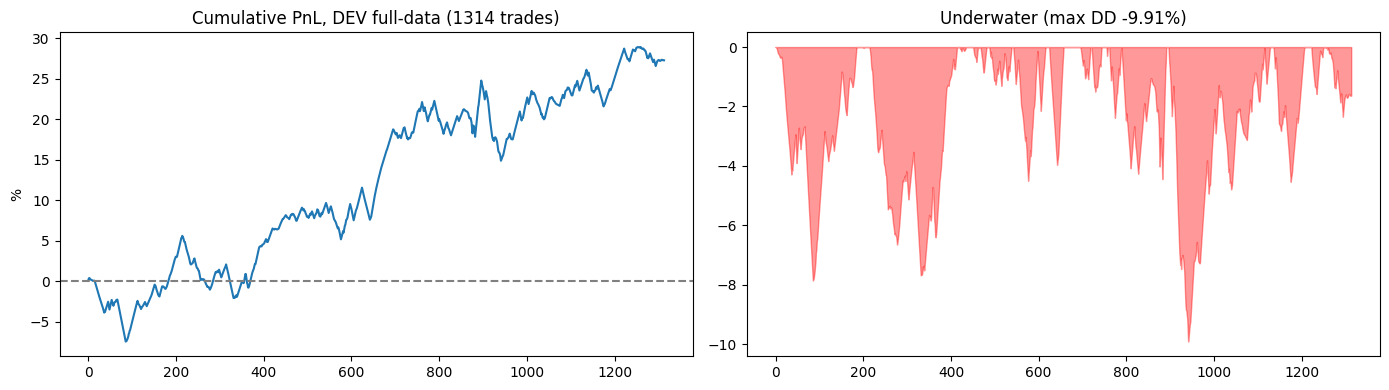


Final DEV equity: +27.28% | Max DD: -9.91%


In [8]:
# === Cell 8: Bootstrap CI and PnL curve on DEV full-data ===
mu, lo, hi = ic_boot(r_model)
print('=== 95% CI of the mean return per trade (DEV full-data) ===')
print(f'  N trades:    {len(r_model):,} ({nL} L, {nS} S)')
print(f'  Mean return: {mu*100:+.4f}%')
print(f'  95% CI:      [{lo*100:+.4f}%, {hi*100:+.4f}%]')
print(f'  Includes zero? {"NO ← significant edge on DEV" if lo>0 else "YES ← edge indistinguishable from zero"}')

# Breakdown by direction
print(f'\n  LONG  ({nL}): mean={r_model[model_dir[model_dir!=0]==1].mean()*100 if nL>0 else float("nan"):+.4f}%')
print(f'  SHORT ({nS}): mean={r_model[model_dir[model_dir!=0]==-1].mean()*100 if nS>0 else float("nan"):+.4f}%')

# Cumulative PnL curve (chronological)
dft = dev_full[model_dir!=0].copy()
dft['ret'] = r_model
dft = dft.sort_values('Datetime')
eq = dft['ret'].cumsum().values*100
peak = np.maximum.accumulate(eq); dd = eq-peak

fig, ax = plt.subplots(1,2,figsize=(14,4))
ax[0].plot(eq); ax[0].axhline(0,color='gray',ls='--')
ax[0].set_title(f'Cumulative PnL, DEV full-data ({len(r_model)} trades)'); ax[0].set_ylabel('%')
ax[1].fill_between(range(len(dd)), dd, 0, color='red', alpha=0.4)
ax[1].set_title(f'Underwater (max DD {dd.min():.2f}%)')
plt.tight_layout(); plt.savefig('../outputs/reports/dev_pnl.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'\nFinal DEV equity: {eq[-1]:+.2f}% | Max DD: {dd.min():.2f}%')

In [9]:
# === Cell 9: Feature importance (gain) ===
imp = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'gain': model.feature_importance(importance_type='gain'),
    'split': model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)
imp['gain_pct'] = imp['gain']/imp['gain'].sum()*100
print('Feature importance (by gain):')
print(imp[['feature','gain_pct','split']].round(2).to_string(index=False))

Feature importance (by gain):
       feature  gain_pct  split
 regime_50_200     19.30    118
  volret_ratio     15.21    122
   tension_200      8.85     72
    slope_long      7.58     56
  regime_20_50      5.96     53
        ret_80      5.91     49
   slope_short      5.15     37
       dow_cos      4.88     40
      ret_20_z      4.72     42
    tension_50      4.55     37
  dist_sma_200      4.27     32
      hour_sin      3.95     33
   dist_sma_50      2.64     21
       dow_sin      2.42     22
      hour_cos      1.97     20
     curvature      1.91     19
       ret_5_z      0.73      7
close_position      0.00      0
    lower_wick      0.00      0
    upper_wick      0.00      0
      body_pct      0.00      0


---
## Walk-forward — temporal consistency check
Trains and predicts independently across TRAIN+DEV. The chosen threshold only filters which trades are scored. The TEST split remains untouched.

In [10]:
# === Cell 10: EXPANDING walk-forward (on TRAIN+DEV, TEST untouched) ===
# EXPANDING training window: training ALWAYS starts at observation 1 and GROWS
# fold by fold (absorbing the previous test block). Test blocks have a fixed size
# and always follow the training window immediately. This mirrors how the bot lives:
# it accumulates the whole history and retrains on all of it, never discarding the past.
#
#   Fold 0: train [0 .. T]          | test [T .. T+B]
#   Fold 1: train [0 .. T+B]        | test [T+B .. T+2B]
#   Fold 2: train [0 .. T+2B]       | test [T+2B .. T+3B]   ...
#
# Trains on FILTERED data (clean TP/SL labels). Evaluates and SHOWS results
# on FILTERED data (optimistic) and FULL-DATA (with TIMEOUT, realistic), side by side.
# The chosen threshold only filters which trades are scored; it does not change the training.

N_FOLDS_WF = 4   # larger test blocks, fewer folds

# --- Filtered TRAIN+DEV data (for training) ---
wf_filt = df[df['Datetime'] <= dev_end].reset_index(drop=True)

# --- Full TRAIN+DEV data (for realistic evaluation) ---
wf_start_dt = wf_filt['Datetime'].min()
wf_full = full[(full['Datetime'] >= wf_start_dt) & (full['Datetime'] <= dev_end)].reset_index(drop=True).copy()
# full-data exits over the whole TRAIN+DEV range
loA, leA, soA, seA = compute_first_hit_full(
    wf_full['High'].values, wf_full['Low'].values, wf_full['Close'].values,
    wf_full['Open'].values, wf_full['atr_exante'].values, K_TP, K_SL, HORIZON)
wf_full['long_outcome']=loA; wf_full['long_exit']=leA
wf_full['short_outcome']=soA; wf_full['short_exit']=seA
wf_full = wf_full.dropna(subset=['long_exit','short_exit']).reset_index(drop=True)

# --- Define the expanding folds on the FILTERED data ---
# initial train = 55% of the filtered data; the rest is split into N_FOLDS test blocks.
n_filt = len(wf_filt)
train_init = int(n_filt * 0.55)
remaining = n_filt - train_init
block = remaining // N_FOLDS_WF

def returns_full_block(d_block, pred, thr_long, thr_short):
    o=d_block['Open'].values; cost=d_block['cost_pct'].values
    le=d_block['long_exit'].values; se=d_block['short_exit'].values
    lm=pred>thr_long; sm=pred<thr_short
    r=np.zeros(len(d_block))
    r[lm]=(le[lm]-o[lm])/o[lm]-RT_COST*cost[lm]
    r[sm]=(o[sm]-se[sm])/o[sm]-RT_COST*cost[sm]
    return r[lm|sm]

def returns_filt_block(d_block, pred, thr_long, thr_short):
    tp=d_block['tp_pct'].values; sl=d_block['sl_pct'].values
    cost=d_block['cost_pct'].values; target=d_block['target'].values
    lm=pred>thr_long; sm=pred<thr_short
    r=np.zeros(len(d_block))
    r[lm]=np.where(target[lm]==1, tp[lm]-RT_COST*cost[lm], -sl[lm]-RT_COST*cost[lm])
    r[sm]=np.where(target[sm]==0, tp[sm]-RT_COST*cost[sm], -sl[sm]-RT_COST*cost[sm])
    return r[lm|sm]

print('='*100)
print(f'  EXPANDING WALK-FORWARD — {N_FOLDS_WF} folds (training starts at obs 0 and grows)')
print(f'  Initial train: {train_init:,} filtered obs | test block: ~{block:,} obs')
print('='*100)

rows=[]
for k in range(N_FOLDS_WF):
    tr_end = train_init + k*block
    te_start = tr_end
    te_end = tr_end + block if k < N_FOLDS_WF-1 else n_filt
    if te_start >= n_filt: break

    tr_block = wf_filt.iloc[:tr_end]          # EXPANDING: always from 0
    te_block_filt = wf_filt.iloc[te_start:te_end]
    if len(te_block_filt) < 50: break

    # Train (filtered data), internal early stopping
    vs2 = int(len(tr_block)*0.8)
    m = lgb.train(LGB_PARAMS,
                  lgb.Dataset(tr_block.iloc[:vs2][SELECTED_FEATURES].values,
                              label=tr_block.iloc[:vs2]['target'].values, feature_name=SELECTED_FEATURES),
                  num_boost_round=N_BOOST_MAX,
                  valid_sets=[lgb.Dataset(tr_block.iloc[vs2:][SELECTED_FEATURES].values,
                              label=tr_block.iloc[vs2:]['target'].values, feature_name=SELECTED_FEATURES)],
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

    # Train and test dates (filtered)
    tr_from, tr_to = tr_block['Datetime'].min(), tr_block['Datetime'].max()
    te_from, te_to = te_block_filt['Datetime'].min(), te_block_filt['Datetime'].max()

    # --- FILTERED evaluation on the test block ---
    p_te_f = m.predict(te_block_filt[SELECTED_FEATURES].values, num_iteration=m.best_iteration)
    auc = roc_auc_score(te_block_filt['target'].values, p_te_f)
    rf = returns_filt_block(te_block_filt, p_te_f, best_thr_long, best_thr_short)

    # --- FULL-DATA evaluation: same test DATES, but all bars ---
    te_block_full = wf_full[(wf_full['Datetime'] >= te_from) & (wf_full['Datetime'] <= te_to)].reset_index(drop=True)
    p_te_full = m.predict(te_block_full[SELECTED_FEATURES].values, num_iteration=m.best_iteration)
    ru = returns_full_block(te_block_full, p_te_full, best_thr_long, best_thr_short)

    rows.append({
        'fold':k, 'train_obs':len(tr_block),
        'train_from':tr_from.date(), 'train_to':tr_to.date(),
        'test_from':te_from.date(), 'test_to':te_to.date(),
        'auc':auc,
        'N_filt':len(rf), 'mean_filt%':rf.mean()*100 if len(rf)>0 else np.nan,
        'sum_filt%':rf.sum()*100 if len(rf)>0 else np.nan, 'hit_filt':(rf>0).mean() if len(rf)>0 else np.nan,
        'N_full':len(ru), 'mean_full%':ru.mean()*100 if len(ru)>0 else np.nan,
        'sum_full%':ru.sum()*100 if len(ru)>0 else np.nan, 'hit_full':(ru>0).mean() if len(ru)>0 else np.nan,
    })

df_wf = pd.DataFrame(rows)

# Show: dates and AUC
print('\n--- Windows and AUC ---')
print(df_wf[['fold','train_obs','train_from','train_to','test_from','test_to','auc']].to_string(index=False))

# Show: FILTERED vs FULL metrics side by side
print('\n--- FILTERED (optimistic) vs FULL-DATA (realistic) results by fold ---')
show = df_wf[['fold','N_filt','mean_filt%','sum_filt%','hit_filt','N_full','mean_full%','sum_full%','hit_full']]
print(show.round(4).to_string(index=False))

# Consistency verdict (on FULL-DATA, the realistic view)
n_pos_full = (df_wf['mean_full%'] > 0).sum()
n_valid = df_wf['mean_full%'].notna().sum()
print(f'\n--- Consistency (on FULL-DATA) ---')
print(f'  Folds with mean_full>0: {n_pos_full}/{n_valid} | Mean AUC: {df_wf["auc"].mean():.4f}')
if n_valid > 0 and n_pos_full >= n_valid*0.75:
    print('  ✓ CONSISTENT — the edge is present in most folds on realistic data')
elif n_valid > 0 and n_pos_full >= n_valid*0.5:
    print('  ~ PARTIAL — the edge is present in half the folds; check whether the negative folds belong to one regime')
else:
    print('  ✗ INCONSISTENT — the edge does not appear stably; strong warning sign')
print('\n  Compare mean_filt% vs mean_full% per fold: a large gap = heavy damage from TIMEOUT bars.')
print('  Compare train_to vs the test dates: high training AUC with negative mean_full = overfitting.')

  EXPANDING WALK-FORWARD — 4 folds (training starts at obs 0 and grows)
  Initial train: 25,180 filtered obs | test block: ~5,150 obs



--- Windows and AUC ---
 fold  train_obs train_from   train_to  test_from    test_to      auc
    0      25180 2022-05-24 2024-02-23 2024-02-23 2024-07-09 0.493116
    1      30330 2022-05-24 2024-07-09 2024-07-10 2024-11-12 0.528493
    2      35480 2022-05-24 2024-11-12 2024-11-12 2025-03-21 0.538301
    3      40630 2022-05-24 2025-03-21 2025-03-21 2025-07-29 0.543935

--- FILTERED (optimistic) vs FULL-DATA (realistic) results by fold ---
 fold  N_filt  mean_filt%  sum_filt%  hit_filt  N_full  mean_full%  sum_full%  hit_full
    0     734     -0.0185   -13.6093    0.4237    1510     -0.0147   -22.2251    0.4424
    1       0         NaN        NaN       NaN       0         NaN        NaN       NaN
    2     126      0.0630     7.9384    0.6905     227      0.0432     9.8108    0.6388
    3     962      0.0134    12.8887    0.5457    1687     -0.0089   -15.0334    0.4843

--- Consistency (on FULL-DATA) ---
  Folds with mean_full>0: 1/3 | Mean AUC: 0.5260
  ✗ INCONSISTENT — the edge 

---
## Temporal stability and circuit breaker

In [11]:
# === Cell 11: Temporal stability on DEV full-data ===
# Is the DEV edge spread over time, or concentrated in one stretch?
dft_s = dev_full[model_dir!=0].copy()
dft_s['ret'] = r_model
dft_s = dft_s.sort_values('Datetime').reset_index(drop=True)

def stab(d, nsplit, label):
    idx=np.array_split(np.arange(len(d)), nsplit); npos=0
    print(f'\n--- {label} ---')
    for j,ix in enumerate(idx):
        sub=d.iloc[ix]['ret'].values
        m,lo,hi=ic_boot(sub)
        if m>0: npos+=1
        print(f'  {label[:-1]} {j+1}: {d.iloc[ix]["Datetime"].min().date()}→{d.iloc[ix]["Datetime"].max().date()} '
              f'| n={len(sub):>4} mean={m*100:+.4f}% CI[{lo*100:+.4f},{hi*100:+.4f}] {"＋" if m>0 else "－"}')
    print(f'  → {npos}/{nsplit} positive')
    return npos

print('='*60); print('  TEMPORAL STABILITY — DEV full-data'); print('='*60)
ph = stab(dft_s, 2, 'Half-periods')
pq = stab(dft_s, 4, 'Quarters')
dft_s['month']=dft_s['Datetime'].dt.to_period('M')
mo=dft_s.groupby('month')['ret'].agg(['count','mean','sum']); mo['mean%']=mo['mean']*100
print(f'\n--- Monthly ---'); print(mo[['count','mean%','sum']].round(4).to_string())
print(f'  → {(mo["mean"]>0).sum()}/{len(mo)} positive months')

  TEMPORAL STABILITY — DEV full-data

--- Half-periods ---
  Half-period 1: 2024-10-17→2025-02-10 | n= 657 mean=+0.0172% CI[+0.0037,+0.0305] ＋
  Half-period 2: 2025-02-10→2025-07-28 | n= 657 mean=+0.0243% CI[+0.0079,+0.0397] ＋
  → 2/2 positive

--- Quarters ---
  Quarter 1: 2024-10-17→2024-12-11 | n= 329 mean=-0.0041% CI[-0.0230,+0.0142] －
  Quarter 2: 2024-12-11→2025-02-10 | n= 329 mean=+0.0392% CI[+0.0196,+0.0589] ＋
  Quarter 3: 2025-02-10→2025-05-01 | n= 328 mean=+0.0278% CI[+0.0002,+0.0543] ＋
  Quarter 4: 2025-05-01→2025-07-28 | n= 328 mean=+0.0201% CI[+0.0016,+0.0387] ＋
  → 3/4 positive

--- Monthly ---
         count   mean%     sum
month                         
2024-10     58 -0.0525 -0.0305
2024-11    190  0.0249  0.0472
2024-12    248  0.0272  0.0675
2025-01     99  0.0036  0.0036
2025-02    168  0.0777  0.1306
2025-03    112 -0.0205 -0.0229
2025-04     93 -0.0221 -0.0205
2025-05    142  0.0461  0.0654
2025-06     66 -0.0372 -0.0246
2025-07    138  0.0413  0.0570
  → 6/10 pos

In [12]:
# === Cell 12: Drawdown circuit breaker — choosing the cooldown ===
# Builds the chronological sequence of trades on DEV full-data and sweeps cooldowns.
# Result: the cooldown + DD threshold that become part of the "final model".
#
# NOTE on magnitudes: this runs on DEV (~20% of the data), so the number of trades
# is smaller than in a backtest over the whole history. What matters is the
# PROFILE: mean/trade, hit rate, and how the cooldown improves the max DD.

DD_THRESHOLD = -0.05

bdf = dev_full[model_dir!=0].copy()
bdf['reward'] = r_model
bdf = bdf.rename(columns={'Datetime':'entry_dt'}).sort_values('entry_dt').reset_index(drop=True)
bdf['exit_dt'] = bdf['entry_dt'] + pd.Timedelta(minutes=15*HORIZON)

def apply_breaker(d, cooldown_h, dd_th):
    cd=pd.Timedelta(hours=cooldown_h); cum=0.0; peak=0.0; until=None
    acts=[]; cums=[]
    for i in range(len(d)):
        t=d['entry_dt'].iloc[i]
        if until is not None and t<until:
            acts.append('SKIP'); cums.append(cum); continue
        until=None
        cum+=d['reward'].iloc[i]; peak=max(peak,cum)
        acts.append('TAKE'); cums.append(cum)
        if (cum-peak)<=dd_th: until=t+cd
    d=d.copy(); d['act']=acts; d['cum']=cums
    d['dd']=d['cum']-np.maximum.accumulate(d['cum'])
    taken=d[d['act']=='TAKE']
    if len(taken)<30: return None
    r=taken['reward'].values
    rng=np.random.default_rng(42)
    mm=np.array([r[rng.integers(0,len(r),len(r))].mean() for _ in range(1000)])
    return {'n_taken':len(taken),'n_skip':int((d['act']=='SKIP').sum()),
            'mean%':r.mean()*100,'sum%':r.sum()*100,'hit':(r>0).mean(),
            'max_dd%':d['dd'].min()*100,'ic_lo%':np.percentile(mm,2.5)*100,
            'ic>0':np.percentile(mm,2.5)>0}

base = apply_breaker(bdf, 0, DD_THRESHOLD)
print('='*70); print(f'  COOLDOWN SWEEP (trigger DD<={DD_THRESHOLD*100:.0f}%) — DEV full-data'); print('='*70)
print(f'\nBaseline (no cooldown): N={base["n_taken"]} sum={base["sum%"]:+.2f}% '
      f'mean={base["mean%"]:+.4f}% hit={base["hit"]:.4f} maxDD={base["max_dd%"]:.2f}%\n')
print(f'{"Cooldown_h":>10} {"N":>6} {"Skip":>6} {"mean%":>9} {"sum%":>9} {"hit":>6} {"maxDD%":>9} {"IC>0":>5}')
print('-'*70)
cands=[1.0,1.8,2.0,4.0,6.0,8.0,12.0,24.0,48.0,72.0]
rows=[]
for h in cands:
    res=apply_breaker(bdf,h,DD_THRESHOLD)
    if res is None: continue
    print(f'{h:>10.1f} {res["n_taken"]:>6} {res["n_skip"]:>6} {res["mean%"]:>+8.4f} '
          f'{res["sum%"]:>+8.2f} {res["hit"]:>6.4f} {res["max_dd%"]:>+8.2f} {"YES" if res["ic>0"] else "NO":>5}')
    rows.append({'cooldown_h':h, **res})
sw=pd.DataFrame(rows)

print('\n' + '='*70); print('  RECOMMENDATION'); print('='*70)
if len(sw)>0:
    sw['ret_to_dd']=sw['sum%']/sw['max_dd%'].abs()
    b_sum=sw.loc[sw['sum%'].idxmax()]
    b_radj=sw.loc[sw['ret_to_dd'].idxmax()]
    b_dd=sw.loc[sw['max_dd%'].idxmax()]
    print(f'  Best sum%:         {b_sum["cooldown_h"]:.1f}h → sum={b_sum["sum%"]:+.2f}% maxDD={b_sum["max_dd%"]:.2f}%')
    print(f'  Best return/|DD|:  {b_radj["cooldown_h"]:.1f}h → ratio={b_radj["ret_to_dd"]:.2f} maxDD={b_radj["max_dd%"]:.2f}%')
    print(f'  Lowest DD:         {b_dd["cooldown_h"]:.1f}h → maxDD={b_dd["max_dd%"]:.2f}% sum={b_dd["sum%"]:+.2f}%')
    print(f'\n  Baseline:          sum={base["sum%"]:+.2f}% maxDD={base["max_dd%"]:.2f}%')

# Fixed choice (set by hand after reviewing the sweep above):
COOLDOWN_HOURS = 4.0
print(f'\n  → Cooldown chosen for the final model: {COOLDOWN_HOURS}h (DD trigger {DD_THRESHOLD*100:.0f}%)')

  COOLDOWN SWEEP (trigger DD<=-5%) — DEV full-data

Baseline (no cooldown): N=1314 sum=+27.28% mean=+0.0208% hit=0.5601 maxDD=-9.91%

Cooldown_h      N   Skip     mean%      sum%    hit    maxDD%  IC>0
----------------------------------------------------------------------
       1.0   1200    114  +0.0236   +28.28 0.5617    -6.49   YES
       1.8   1175    139  +0.0237   +27.83 0.5617    -5.83   YES


       2.0   1175    139  +0.0237   +27.83 0.5617    -5.83   YES
       4.0   1141    173  +0.0233   +26.62 0.5635    -5.82   YES
       6.0    884    430  +0.0242   +21.37 0.5690    -5.82   YES


       8.0    902    412  +0.0241   +21.74 0.5632    -5.82   YES
      12.0    828    486  +0.0191   +15.80 0.5556    -6.80   YES
      24.0    832    482  +0.0264   +21.96 0.5709    -5.64   YES


      48.0    741    573  +0.0172   +12.74 0.5520    -5.81   YES
      72.0    414    900  +0.0092    +3.80 0.5314    -6.00    NO

  RECOMMENDATION
  Best sum%:         1.0h → sum=+28.28% maxDD=-6.49%
  Best return/|DD|:  1.8h → ratio=4.77 maxDD=-5.83%
  Lowest DD:         24.0h → maxDD=-5.64% sum=+21.96%

  Baseline:          sum=+27.28% maxDD=-9.91%

  → Cooldown chosen for the final model: 4.0h (DD trigger -5%)


---
## Final model

In [13]:
# === Cell 13: FINAL MODEL summary (complete settings) ===
# At this point the complete model is defined. What remains is its single evaluation
# on the untouched TEST split (final section of this notebook). The .pkl artifact
# is produced separately by scripts/export_model.py from this same configuration.

print('='*70)
print('  FINAL MODEL — COMPLETE CONFIGURATION')
print('='*70)
print(f'''
  Asset / timeframe:  USDJPY 15M
  Features:           {len(SELECTED_FEATURES)}
  K_TP / K_SL:        {K_TP} / {K_SL}
  Horizon:            {HORIZON} bars ({HORIZON*15/60:.1f}h)
  LONG threshold:     > {best_thr_long}
  SHORT threshold:    < {best_thr_short}
  Circuit breaker:    DD <= {DD_THRESHOLD*100:.0f}% → cooldown {COOLDOWN_HOURS}h
  best_iteration:     {model.best_iteration}

  Threshold chosen on DEV (full-data). Walk-forward consistency: see the output of cell 10.
  Remaining: the one-time validation on the untouched TEST split (next section).
''')
print('  Next: the final section evaluates this frozen model on the TEST split, once.')
print('  Deployment is only considered if the model passes those pre-registered checks.')

  FINAL MODEL — COMPLETE CONFIGURATION

  Asset / timeframe:  USDJPY 15M
  Features:           21
  K_TP / K_SL:        2.5 / 2.5
  Horizon:            18 bars (4.5h)
  LONG threshold:     > 0.55
  SHORT threshold:    < 0.45
  Circuit breaker:    DD <= -5% → cooldown 4.0h
  best_iteration:     26

  Threshold chosen on DEV (full-data). Walk-forward consistency: see the output of cell 10.
  Remaining: the one-time validation on the untouched TEST split (next section).

  Next: the final section evaluates this frozen model on the TEST split, once.
  Deployment is only considered if the model passes those pre-registered checks.


---
# Validation on the TEST split (never-seen data)

**⚠️ Read once.** The following cells apply the FROZEN model (the same `model`, `best_thr_long/short` and `COOLDOWN_HOURS` defined above) to the TEST split, which stayed locked for the whole notebook. This is the final gate. If anything is changed after seeing the result and the notebook is re-run, the test loses its value as an unbiased estimate.

*Re-running the notebook end to end without changing anything (for example, to reproduce these outputs) does not affect this: the model and every parameter are fixed before this section executes.*

In [14]:
# === Cell 14: VALIDATION ON TEST (never seen) — preparation ===
# ⚠️  GOLDEN RULE: the TEST split is looked at ONCE, with the model FROZEN.
#     Changing the threshold/K/cooldown after seeing this and re-running the test
#     would make it biased. This cell uses the model, thresholds and cooldown
#     ALREADY defined above (the same `model` object, best_thr_long/short, COOLDOWN_HOURS).
#
# The TEST full-data set (all bars, including TIMEOUT) is built from the unfiltered
# parquet, exits are computed, and the frozen model is applied.

test_start, test_end = test['Datetime'].min(), test['Datetime'].max()
test_full = full[(full['Datetime'] >= test_start) & (full['Datetime'] <= test_end)].reset_index(drop=True).copy()

lo, le, so, se = compute_first_hit_full(
    test_full['High'].values, test_full['Low'].values, test_full['Close'].values,
    test_full['Open'].values, test_full['atr_exante'].values, K_TP, K_SL, HORIZON)
test_full['long_outcome']=lo; test_full['long_exit']=le
test_full['short_outcome']=so; test_full['short_exit']=se
test_full['pred_proba'] = model.predict(test_full[SELECTED_FEATURES].values, num_iteration=model.best_iteration)
test_full = test_full.dropna(subset=['long_exit','short_exit']).reset_index(drop=True)

print('='*70)
print('  VALIDATION ON TEST — data NEVER seen by the model')
print('='*70)
print(f'  TEST period: {test_start.date()} → {test_end.date()}')
print(f'  Full-data bars in TEST: {len(test_full):,}')
print(f'  FROZEN model: thr LONG>{best_thr_long} SHORT<{best_thr_short} | '
      f'cooldown {COOLDOWN_HOURS}h @ DD{DD_THRESHOLD*100:.0f}%')
print(f'  best_iteration={model.best_iteration} (same model as cell 3)')

  VALIDATION ON TEST — data NEVER seen by the model
  TEST period: 2025-07-29 → 2026-05-27
  Full-data bars in TEST: 20,550
  FROZEN model: thr LONG>0.55 SHORT<0.45 | cooldown 4.0h @ DD-5%
  best_iteration=26 (same model as cell 3)


In [15]:
# === Cell 15: Model trades on TEST (round-trip cost and cooldown applied) ===
predT = test_full['pred_proba'].values
dirT = np.where(predT>best_thr_long, 1, np.where(predT<best_thr_short, -1, 0))

oT=test_full['Open'].values; costT=test_full['cost_pct'].values
leT=test_full['long_exit'].values; seT=test_full['short_exit'].values
retT=np.zeros(len(test_full))
lmT=dirT==1; smT=dirT==-1
retT[lmT]=(leT[lmT]-oT[lmT])/oT[lmT]-RT_COST*costT[lmT]
retT[smT]=(oT[smT]-seT[smT])/oT[smT]-RT_COST*costT[smT]

tt = test_full[dirT!=0].copy()
tt['dir']=np.where(dirT[dirT!=0]==1,'LONG','SHORT')
tt['ret']=retT[dirT!=0]
tt['long_ret']=(leT[dirT!=0]-oT[dirT!=0])/oT[dirT!=0]-RT_COST*costT[dirT!=0]
tt['short_ret']=(oT[dirT!=0]-seT[dirT!=0])/oT[dirT!=0]-RT_COST*costT[dirT!=0]
tt=tt.rename(columns={'Datetime':'entry_dt'}).sort_values('entry_dt').reset_index(drop=True)

# Apply the cooldown (same rule as cell 12)
def apply_cd(d, cooldown_h, dd_th):
    cd=pd.Timedelta(hours=cooldown_h); cum=0.0; peak=0.0; until=None; act=[]
    for i in range(len(d)):
        t=d['entry_dt'].iloc[i]
        if until is not None and t<until: act.append('SKIP'); continue
        until=None; cum+=d['ret'].iloc[i]; peak=max(peak,cum); act.append('TAKE')
        if (cum-peak)<=dd_th: until=t+cd
    d=d.copy(); d['act']=act; return d

tt = apply_cd(tt, COOLDOWN_HOURS, DD_THRESHOLD)
taken = tt[tt['act']=='TAKE'].copy()
r = taken['ret'].values

print(f'Signals in TEST: {len(tt)} ({(tt["dir"]=="LONG").sum()}L/{(tt["dir"]=="SHORT").sum()}S)')
print(f'Trades taken (post-cooldown): {len(taken)} | skipped: {(tt["act"]=="SKIP").sum()}')
if len(r)<30:
    print('⚠️  Too few trades in TEST for firm conclusions — read the CI with caution.')
print(f'\nMean return/trade: {r.mean()*100:+.4f}%' if len(r)>0 else 'no trades')
print(f'Sum return:        {r.sum()*100:+.2f}%' if len(r)>0 else '')
print(f'Hit rate:          {(r>0).mean():.4f}' if len(r)>0 else '')

Signals in TEST: 2137 (1489L/648S)
Trades taken (post-cooldown): 894 | skipped: 1243

Mean return/trade: +0.0092%
Sum return:        +8.23%
Hit rate:          0.5503


In [16]:
# === Cell 16: The robustness tests on the never-seen TEST split ===
print('='*70); print('  ROBUSTNESS TESTS ON NEVER-SEEN DATA'); print('='*70)

def ic_boot(x, n_boot=5000, seed=42):
    if len(x)<20: return np.nan, np.nan, np.nan
    rng=np.random.default_rng(seed)
    m=np.array([x[rng.integers(0,len(x),len(x))].mean() for _ in range(n_boot)])
    return x.mean(), np.percentile(m,2.5), np.percentile(m,97.5)

# Global guard: with no trades there is nothing to test.
if len(r) == 0:
    print('\n✗ ZERO trades in TEST with this configuration.')
    print('  Robustness cannot be evaluated. Possible causes:')
    print('  - Thresholds too strict for the distribution of probabilities in the test.')
    print('  - The cooldown blocking everything after an early drawdown.')
    test_results = dict(edge_ok=False, timing_ok=False, robust_week=False,
                        halves_pos=0, mean=np.nan, ic_lo=np.nan, ic_hi=np.nan,
                        pct=np.nan, n=0, null=np.array([0.0]))
else:
    # ---------- Test 1: CI ----------
    mu, lo, hi = ic_boot(r)
    print(f'\n[1] EDGE ON TEST')
    print(f'    N={len(r)} | mean={mu*100:+.4f}% | CI95[{lo*100:+.4f}%, {hi*100:+.4f}%]' if not np.isnan(mu)
          else f'    N={len(r)} (too few for a reliable CI)')
    edge_ok = (not np.isnan(lo)) and (lo > 0)
    print(f'    {"✓ CI excludes zero — edge confirmed on never-seen data" if edge_ok else "✗ CI includes zero / low N — edge NOT confirmed on the test"}')

    # ---------- Test 2: Timing vs drift ----------
    nL=int((taken["dir"]=="LONG").sum()); nS=int((taken["dir"]=="SHORT").sum())
    lr=taken['long_ret'].values; sr=taken['short_ret'].values
    rng=np.random.default_rng(42); B=5000
    labels=np.array([1]*nL+[-1]*nS)
    null=np.empty(B)
    for b in range(B):
        p=rng.permutation(labels)
        null[b]=np.where(p==1,lr,sr).sum()
    model_sum=r.sum()
    pct=(null<model_sum).mean()*100
    print(f'\n[2] TIMING vs DRIFT (exposure-matched null)')
    print(f'    Model sum={model_sum*100:+.2f}% | null mean={null.mean()*100:+.2f}% '
          f'p95={np.percentile(null,95)*100:+.2f}%')
    print(f'    Model at percentile {pct:.1f} of the null')
    timing_ok = pct>=95
    print(f'    {"✓ Beats the exposure-matched null — real timing" if timing_ok else "✗ Does NOT beat the null — drift capture, not timing"}')

    # ---------- Test 3: Stress ----------
    print(f'\n[3] DISTRIBUTION STRESS')
    total=r.sum()
    for k in [1,5]:
        if k<len(r):
            wo=np.sort(r)[:-k].sum()
            print(f'    Without the top {k} trade(s): {wo*100:+.2f}% (from {total*100:+.2f}%)')
    taken['week']=taken['entry_dt'].dt.to_period('W')
    wk=taken.groupby('week')['ret'].sum()
    wo_best_week = total - wk.max() if len(wk)>0 else total
    robust_week = wo_best_week>0
    print(f'    Without the best week: {wo_best_week*100:+.2f}%  '
          f'{"✓ survives" if robust_week else "✗ the edge disappears"}')
    eq=np.cumsum(r); dd=eq-np.maximum.accumulate(eq)
    print(f'    Max DD (cumulative return): {dd.min()*100:.2f}%')

    # ---------- Test 4: Stability ----------
    print(f'\n[4] STABILITY WITHIN THE TEST')
    th=taken.sort_values('entry_dt').reset_index(drop=True)
    hp=0
    if len(th) >= 4:
        for j,ix in enumerate(np.array_split(np.arange(len(th)),2)):
            sub=th.iloc[ix]['ret'].values
            m2,_,_=ic_boot(sub) if len(sub)>=20 else (sub.mean() if len(sub)>0 else np.nan,0,0)
            if not np.isnan(m2) and m2>0: hp+=1
            print(f'    Half {j+1}: n={len(sub)} mean={m2*100:+.4f}% {"＋" if (not np.isnan(m2) and m2>0) else "－"}')
    else:
        print('    Too few trades to split into halves.')
    print(f'    → {hp}/2 positive halves')

    test_results = dict(edge_ok=edge_ok, timing_ok=timing_ok, robust_week=robust_week,
                        halves_pos=hp, mean=mu, ic_lo=lo, ic_hi=hi, pct=pct, n=len(r), null=null)

  ROBUSTNESS TESTS ON NEVER-SEEN DATA

[1] EDGE ON TEST
    N=894 | mean=+0.0092% | CI95[+0.0002%, +0.0181%]
    ✓ CI excludes zero — edge confirmed on never-seen data

[2] TIMING vs DRIFT (exposure-matched null)
    Model sum=+8.23% | null mean=-4.99% p95=+1.26%
    Model at percentile 100.0 of the null
    ✓ Beats the exposure-matched null — real timing

[3] DISTRIBUTION STRESS
    Without the top 1 trade(s): +7.81% (from +8.23%)
    Without the top 5 trade(s): +6.77% (from +8.23%)
    Without the best week: +1.00%  ✓ survives
    Max DD (cumulative return): -7.72%

[4] STABILITY WITHIN THE TEST


    Half 1: n=447 mean=+0.0174% ＋
    Half 2: n=447 mean=+0.0010% ＋
    → 2/2 positive halves


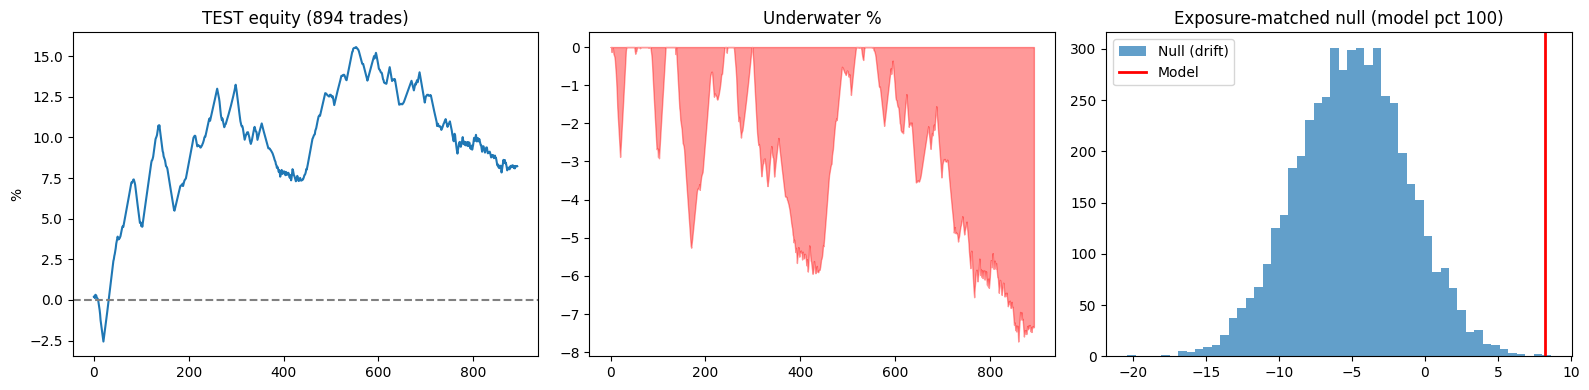

  FINAL VERDICT — LOCKED TEST

  [✓] Significant edge (CI>0 on test)            CI[+0.0002,+0.0181]
  [✓] Real timing (> exposure-matched null)      pct 100.0
  [✓] Survives without the best week             
  [✓] Stable (2/2 positive halves)               2/2

  4/4 criteria met on never-seen data

  ✓ ALL PRE-REGISTERED CHECKS PASSED on the locked test. (A marginal pass is not a deployable edge: see Section 5 of the technical report.)

  Reminder: the TEST split is looked at once, and it has now been seen. Changing anything
  and re-running would make the result biased. The decision (continue, change approach,
  or stop) is made with THIS number, not by searching for a better one.



In [17]:
# === Cell 17: TEST verdict + plots ===
import matplotlib.pyplot as plt
null = test_results.get('null', np.array([0.0]))
if test_results['n'] > 0:
    fig, ax = plt.subplots(1,3, figsize=(16,4))
    eq=np.cumsum(r)*100
    ax[0].plot(eq); ax[0].axhline(0,color='gray',ls='--')
    ax[0].set_title(f'TEST equity ({len(r)} trades)'); ax[0].set_ylabel('%')
    ddp=(np.cumsum(r)-np.maximum.accumulate(np.cumsum(r)))*100
    ax[1].fill_between(range(len(ddp)),ddp,0,color='red',alpha=0.4); ax[1].set_title('Underwater %')
    ax[2].hist(null*100,bins=50,alpha=0.7,label='Null (drift)')
    ax[2].axvline(r.sum()*100,color='red',lw=2,label='Model')
    ax[2].set_title(f'Exposure-matched null (model pct {test_results["pct"]:.0f})'); ax[2].legend()
    plt.tight_layout(); plt.savefig('../outputs/reports/test_validation.png',dpi=100,bbox_inches='tight'); plt.show()

print('='*70); print('  FINAL VERDICT — LOCKED TEST'); print('='*70)
if test_results['n']==0:
    print('\n  ✗ No trades in the test: no verdict is possible with this configuration.')
else:
    checks=[
        ('Significant edge (CI>0 on test)', test_results['edge_ok'],
         f'CI[{test_results["ic_lo"]*100:+.4f},{test_results["ic_hi"]*100:+.4f}]'),
        ('Real timing (> exposure-matched null)', test_results['timing_ok'], f'pct {test_results["pct"]:.1f}'),
        ('Survives without the best week', test_results['robust_week'], ''),
        ('Stable (2/2 positive halves)', test_results['halves_pos']==2, f'{test_results["halves_pos"]}/2'),
    ]
    npass=sum(c[1] for c in checks)
    print()
    for name,ok,val in checks:
        print(f'  [{"✓" if ok else "✗"}] {name:<42} {val}')
    print(f'\n  {npass}/{len(checks)} criteria met on never-seen data\n')
    if npass==len(checks):
        print('  ✓ ALL PRE-REGISTERED CHECKS PASSED on the locked test. (A marginal pass is not a deployable edge: see Section 5 of the technical report.)')
    elif npass>=3:
        print('  ~ PARTIAL. Some signal, with serious reservations. Do NOT re-optimize on the test.')
    else:
        print('  ✗ FAILS. On never-seen data, the edge does not hold.')
        print('    This honestly closes the case for this model/configuration.')

print('''
  Reminder: the TEST split is looked at once, and it has now been seen. Changing anything
  and re-running would make the result biased. The decision (continue, change approach,
  or stop) is made with THIS number, not by searching for a better one.
''')